In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:


file_path = "./data/MEDHA_Synthetic_1000x30-1.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Longitudinal_Data"
)

print("Shape:", df.shape)
print(df.head())

Shape: (30000, 83)
  Victim_ID Case_ID  Timepoint  Date_Time        Case_Type     Case_Stage  \
0     V0001   C0001          1 2026-01-01  sexual_violence  Investigation   
1     V0001   C0001          2 2026-01-02  sexual_violence  Investigation   
2     V0001   C0001          3 2026-01-03  sexual_violence  Investigation   
3     V0001   C0001          4 2026-01-04  sexual_violence  Investigation   
4     V0001   C0001          5 2026-01-05  sexual_violence  Investigation   

   Checkin_Available  Mood  Stress  Sleep  ...  DDS_Slope  Recent_Change_Rate  \
0                  1   3.0     4.0    3.0  ...        NaN                 NaN   
1                  1   2.0     3.0    3.0  ...        NaN           13.640000   
2                  1   4.0     4.0    2.0  ...      2.005            2.005000   
3                  1   2.0     3.0    2.0  ...      1.509            2.746667   
4                  1   3.0     3.0    2.0  ...      0.512           -2.793333   

   Behaviour_Trend  Engagement_

In [4]:
print("Number of columns:", len(df.columns))

for i, col in enumerate(df.columns):
    print(i, col)

Number of columns: 83
0 Victim_ID
1 Case_ID
2 Timepoint
3 Date_Time
4 Case_Type
5 Case_Stage
6 Checkin_Available
7 Mood
8 Stress
9 Sleep
10 Functioning
11 Safety
12 Social_Support_Checkin
13 Self_Reported_Wellbeing
14 Response_Delay_Hours
15 Missed_Checkin
16 Interaction_Frequency_7d
17 Session_Duration_Minutes
18 Engagement_Score
19 Engagement_Deviation
20 Response_Delay_Deviation
21 Threat_Event
22 Upcoming_Hearing
23 Hearing_Completed
24 Investigation_Delay
25 Compensation_Delay
26 Relocation_Stress
27 Rehabilitation_Issue
28 Protection_Event
29 Family_Support
30 Social_Support
31 Therapist_Engagement
32 Access_To_Services
33 Stable_Housing
34 Other_Protective_Factors
35 Text_Available
36 Text_Distress
37 Fear
38 Threat_Context
39 Negative_Affect
40 Urgency
41 Voice_Available
42 Voice_Distress
43 Pause_Ratio
44 Speech_Rate_Deviation
45 Energy_Deviation
46 Acoustic_Indicator
47 Diary_Available
48 Diary_Length
49 Diary_Distress_Feature
50 Therapist_Observation_Available
51 Therapist_O

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 83 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Victim_ID                        30000 non-null  str           
 1   Case_ID                          30000 non-null  str           
 2   Timepoint                        30000 non-null  int64         
 3   Date_Time                        30000 non-null  datetime64[us]
 4   Case_Type                        30000 non-null  str           
 5   Case_Stage                       30000 non-null  str           
 6   Checkin_Available                30000 non-null  int64         
 7   Mood                             26955 non-null  float64       
 8   Stress                           26955 non-null  float64       
 9   Sleep                            26955 non-null  float64       
 10  Functioning                      26955 non-null  float64       
 11  

In [5]:
pd.set_option("display.max_rows", 100)

print(df.dtypes)

Victim_ID                                     str
Case_ID                                       str
Timepoint                                   int64
Date_Time                          datetime64[us]
Case_Type                                     str
Case_Stage                                    str
Checkin_Available                           int64
Mood                                      float64
Stress                                    float64
Sleep                                     float64
Functioning                               float64
Safety                                    float64
Social_Support_Checkin                    float64
Self_Reported_Wellbeing                   float64
Response_Delay_Hours                      float64
Missed_Checkin                              int64
Interaction_Frequency_7d                    int64
Session_Duration_Minutes                  float64
Engagement_Score                          float64
Engagement_Deviation                      float64


In [6]:
print("Future_Escalation_Label" in df.columns)
print(df["Future_Escalation_Label"].value_counts(dropna=False))
print(
    df["Future_Escalation_Label"]
    .value_counts(normalize=True, dropna=False)
)

True
Future_Escalation_Label
0.0    21389
NaN     7000
1.0     1611
Name: count, dtype: int64
Future_Escalation_Label
0.0    0.712967
NaN    0.233333
1.0    0.053700
Name: proportion, dtype: float64


In [7]:
model_df = df[
    df["Future_Escalation_Label"].notna()
].copy()

print("Original:", len(df))
print("Usable for ML:", len(model_df))

Original: 30000
Usable for ML: 23000


In [8]:
print(
    model_df.groupby("Victim_ID")
    .size()
    .describe()
)

count    1000.0
mean       23.0
std         0.0
min        23.0
25%        23.0
50%        23.0
75%        23.0
max        23.0
dtype: float64


In [8]:
print(
    model_df.groupby("Victim_ID")["Timepoint"]
    .agg(["min", "max", "count"])
    .head(10)
)

           min  max  count
Victim_ID                 
V0001        1   23     23
V0002        1   23     23
V0003        1   23     23
V0004        1   23     23
V0005        1   23     23
V0006        1   23     23
V0007        1   23     23
V0008        1   23     23
V0009        1   23     23
V0010        1   23     23


In [9]:
victims = model_df["Victim_ID"].unique().to_numpy()

train_victims, temp_victims = train_test_split(
    victims,
    test_size=0.30,
    random_state=42
)

val_victims, test_victims = train_test_split(
    temp_victims,
    test_size=0.50,
    random_state=42
)

print("Train victims:", len(train_victims))
print("Validation victims:", len(val_victims))
print("Test victims:", len(test_victims))

Train victims: 700
Validation victims: 150
Test victims: 150


In [10]:
train_df = model_df[
    model_df["Victim_ID"].isin(train_victims)
].copy()

val_df = model_df[
    model_df["Victim_ID"].isin(val_victims)
].copy()

test_df = model_df[
    model_df["Victim_ID"].isin(test_victims)
].copy()

In [11]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (16100, 83)
Validation: (3450, 83)
Test: (3450, 83)


In [12]:
train_ids = set(train_df["Victim_ID"])
val_ids = set(val_df["Victim_ID"])
test_ids = set(test_df["Victim_ID"])

print("Train ∩ Val:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Val ∩ Test:", len(val_ids & test_ids))

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [13]:
structured_features = [
    # Current check-in / wellbeing
    "Mood",
    "Stress",
    "Sleep",
    "Functioning",
    "Safety",
    "Social_Support_Checkin",
    "Self_Reported_Wellbeing",

    # Case / contextual events
    "Threat_Event",
    "Upcoming_Hearing",
    "Hearing_Completed",
    "Investigation_Delay",
    "Compensation_Delay",
    "Relocation_Stress",
    "Rehabilitation_Issue",
    "Protection_Event",

    # Protective factors
    "Family_Support",
    "Social_Support",
    "Therapist_Engagement",
    "Access_To_Services",
    "Stable_Housing",
    "Other_Protective_Factors",

    # Episode / professional context
    "Recent_Episode",
    "Episode_Severity",
    "Family_Reported_Episode",

    # Current case metadata
    "Case_Type",
    "Case_Stage"
]

In [14]:
missing_features = [
    col for col in structured_features
    if col not in model_df.columns
]

print("Missing features:", missing_features)
print("Number of selected features:", len(structured_features))
print(model_df[structured_features].dtypes)

Missing features: []
Number of selected features: 26
Mood                        float64
Stress                      float64
Sleep                       float64
Functioning                 float64
Safety                      float64
Social_Support_Checkin      float64
Self_Reported_Wellbeing     float64
Threat_Event                  int64
Upcoming_Hearing              int64
Hearing_Completed             int64
Investigation_Delay           int64
Compensation_Delay            int64
Relocation_Stress             int64
Rehabilitation_Issue          int64
Protection_Event              int64
Family_Support              float64
Social_Support              float64
Therapist_Engagement        float64
Access_To_Services          float64
Stable_Housing              float64
Other_Protective_Factors    float64
Recent_Episode                int64
Episode_Severity                str
Family_Reported_Episode       int64
Case_Type                       str
Case_Stage                      str
dtype: obje

In [20]:
print(
    model_df[structured_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

Episode_Severity            22846
Mood                         2374
Sleep                        2374
Functioning                  2374
Safety                       2374
Social_Support_Checkin       2374
Self_Reported_Wellbeing      2374
Stress                       2374
Upcoming_Hearing                0
Threat_Event                    0
Hearing_Completed               0
Investigation_Delay             0
Relocation_Stress               0
Compensation_Delay              0
Protection_Event                0
Family_Support                  0
Social_Support                  0
Rehabilitation_Issue            0
Therapist_Engagement            0
Access_To_Services              0
Other_Protective_Factors        0
Stable_Housing                  0
Recent_Episode                  0
Family_Reported_Episode         0
Case_Type                       0
Case_Stage                      0
dtype: int64


In [15]:
checkin_cols = [
    "Mood",
    "Stress",
    "Sleep",
    "Functioning",
    "Safety",
    "Social_Support_Checkin",
    "Self_Reported_Wellbeing"
]

print(
    model_df[checkin_cols].isna().sum(axis=1).value_counts()
)
print(
    model_df.loc[
        model_df[checkin_cols].isna().any(axis=1),
        ["Victim_ID", "Timepoint"] + checkin_cols
    ].head(20)
)

0    20626
7     2374
Name: count, dtype: int64
    Victim_ID  Timepoint  Mood  Stress  Sleep  Functioning  Safety  \
7       V0001          8   NaN     NaN    NaN          NaN     NaN   
11      V0001         12   NaN     NaN    NaN          NaN     NaN   
12      V0001         13   NaN     NaN    NaN          NaN     NaN   
30      V0002          1   NaN     NaN    NaN          NaN     NaN   
76      V0003         17   NaN     NaN    NaN          NaN     NaN   
90      V0004          1   NaN     NaN    NaN          NaN     NaN   
93      V0004          4   NaN     NaN    NaN          NaN     NaN   
97      V0004          8   NaN     NaN    NaN          NaN     NaN   
109     V0004         20   NaN     NaN    NaN          NaN     NaN   
139     V0005         20   NaN     NaN    NaN          NaN     NaN   
152     V0006          3   NaN     NaN    NaN          NaN     NaN   
189     V0007         10   NaN     NaN    NaN          NaN     NaN   
210     V0008          1   NaN     NaN    

In [16]:
print(
    model_df[model_df["Previous_DDS"].isna()]
    .groupby("Victim_ID")
    .size()
    .describe()
)
print(
    model_df.loc[
        model_df["Previous_DDS"].isna(),
        ["Victim_ID", "Timepoint", "DDS", "Previous_DDS", "Delta_DDS"]
    ].head(20)
)

count    1000.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
dtype: float64
    Victim_ID  Timepoint    DDS  Previous_DDS  Delta_DDS
0       V0001          1  34.63           NaN        NaN
30      V0002          1  37.53           NaN        NaN
60      V0003          1  48.05           NaN        NaN
90      V0004          1  28.69           NaN        NaN
120     V0005          1  36.43           NaN        NaN
150     V0006          1  35.33           NaN        NaN
180     V0007          1  20.54           NaN        NaN
210     V0008          1  22.81           NaN        NaN
240     V0009          1  35.91           NaN        NaN
270     V0010          1   6.72           NaN        NaN
300     V0011          1  20.04           NaN        NaN
330     V0012          1  21.68           NaN        NaN
360     V0013          1  26.82           NaN        NaN
390     V0014          1   0.00           NaN        NaN
42

In [23]:
print(
    pd.crosstab(
        model_df["Recent_Episode"],
        model_df["Episode_Severity"].isna(),
        margins=True
    )
)

Episode_Severity  False   True    All
Recent_Episode                       
0                     0  22846  22846
1                   154      0    154
All                 154  22846  23000


In [24]:
print(model_df["Episode_Severity"].value_counts(dropna=False))

Episode_Severity
NaN         22846
Low            69
Moderate       63
High           22
Name: count, dtype: int64


In [25]:
print(model_df["Case_Type"].value_counts(dropna=False))
print()
print(model_df["Case_Stage"].value_counts(dropna=False))
print(model_df[["Case_Type", "Case_Stage"]].dtypes)

Case_Type
sexual_violence                4117
witness_intimidation           4071
murder_grievous_hurt           3956
caste_based_violence           3887
arson_displacement             3680
compensation_rehabilitation    3289
Name: count, dtype: int64

Case_Stage
Investigation          7124
Compensation           6492
Trial_Preparation      5982
Investigation_Delay    1138
Complaint              1000
Post_Hearing            634
Hearing                 630
Name: count, dtype: int64
Case_Type     str
Case_Stage    str
dtype: object


In [17]:
X_train = train_df[structured_features].copy()
y_train = train_df["Future_Escalation_Label"].astype(int)

X_val = val_df[structured_features].copy()
y_val = val_df["Future_Escalation_Label"].astype(int)

X_test = test_df[structured_features].copy()
y_test = test_df["Future_Escalation_Label"].astype(int)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (16100, 26)
X_val: (3450, 26)
X_test: (3450, 26)
y_train: (16100,)
y_val: (3450,)
y_test: (3450,)


In [27]:
categorical_features = [
    "Episode_Severity",
    "Case_Type",
    "Case_Stage"
]

numeric_features = [
    col for col in structured_features
    if col not in categorical_features
]

print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))

Numeric: 23
Categorical: 3


In [28]:
episode_mapping = {
    "Low": 1,
    "Moderate": 2,
    "High": 3
}

for data in [X_train, X_val, X_test]:
    data["Episode_Severity"] = (
        data["Episode_Severity"]
        .map(episode_mapping)
    )

In [29]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoder.fit(
    X_train[["Case_Type", "Case_Stage"]]
)

train_cat = encoder.transform(
    X_train[["Case_Type", "Case_Stage"]]
)

val_cat = encoder.transform(
    X_val[["Case_Type", "Case_Stage"]]
)

test_cat = encoder.transform(
    X_test[["Case_Type", "Case_Stage"]]
)

In [30]:
import pandas as pd

train_cat_df = pd.DataFrame(
    train_cat,
    columns=encoder.get_feature_names_out(
        ["Case_Type", "Case_Stage"]
    ),
    index=X_train.index
)

val_cat_df = pd.DataFrame(
    val_cat,
    columns=encoder.get_feature_names_out(
        ["Case_Type", "Case_Stage"]
    ),
    index=X_val.index
)

test_cat_df = pd.DataFrame(
    test_cat,
    columns=encoder.get_feature_names_out(
        ["Case_Type", "Case_Stage"]
    ),
    index=X_test.index
)

In [31]:
X_train_processed = pd.concat(
    [
        X_train[numeric_features + ["Episode_Severity"]],
        train_cat_df
    ],
    axis=1
)

X_val_processed = pd.concat(
    [
        X_val[numeric_features + ["Episode_Severity"]],
        val_cat_df
    ],
    axis=1
)

X_test_processed = pd.concat(
    [
        X_test[numeric_features + ["Episode_Severity"]],
        test_cat_df
    ],
    axis=1
)

In [32]:
print("Processed train:", X_train_processed.shape)
print("Processed val:", X_val_processed.shape)
print("Processed test:", X_test_processed.shape)

Processed train: (16100, 37)
Processed val: (3450, 37)
Processed test: (3450, 37)


In [33]:
print(
    X_train_processed.isna()
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

Episode_Severity           15986
Stress                      1641
Sleep                       1641
Functioning                 1641
Mood                        1641
Safety                      1641
Social_Support_Checkin      1641
Self_Reported_Wellbeing     1641
Threat_Event                   0
Hearing_Completed              0
Investigation_Delay            0
Compensation_Delay             0
Upcoming_Hearing               0
Rehabilitation_Issue           0
Protection_Event               0
dtype: int64


In [34]:
print("TRAIN")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nVALIDATION")
print(y_val.value_counts())
print(y_val.value_counts(normalize=True))

print("\nTEST")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

TRAIN
Future_Escalation_Label
0    14957
1     1143
Name: count, dtype: int64
Future_Escalation_Label
0    0.929006
1    0.070994
Name: proportion, dtype: float64

VALIDATION
Future_Escalation_Label
0    3205
1     245
Name: count, dtype: int64
Future_Escalation_Label
0    0.928986
1    0.071014
Name: proportion, dtype: float64

TEST
Future_Escalation_Label
0    3227
1     223
Name: count, dtype: int64
Future_Escalation_Label
0    0.935362
1    0.064638
Name: proportion, dtype: float64


In [35]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model.fit(
    X_train_processed,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [36]:
val_prob = model.predict_proba(
    X_val_processed
)[:, 1]

print(val_prob[:20])

[0.04970711 0.01763907 0.0131057  0.04923275 0.01724914 0.01266753
 0.09408884 0.04442636 0.03172404 0.02039343 0.07606469 0.07725131
 0.05419343 0.08257504 0.28157195 0.3837366  0.33404455 0.3875993
 0.06160249 0.09201302]


In [37]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

val_pred = (val_prob >= 0.5).astype(int)

print(
    classification_report(
        y_val,
        val_pred,
        digits=4
    )
)

print("ROC-AUC:",
      roc_auc_score(y_val, val_prob))

print("PR-AUC:",
      average_precision_score(y_val, val_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_pred))

              precision    recall  f1-score   support

           0     0.9289    0.9994    0.9629      3205
           1     0.0000    0.0000    0.0000       245

    accuracy                         0.9284      3450
   macro avg     0.4645    0.4997    0.4814      3450
weighted avg     0.8630    0.9284    0.8945      3450

ROC-AUC: 0.801337833105161
PR-AUC: 0.22336468767195508

Confusion Matrix:
[[3203    2]
 [ 245    0]]


In [38]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.96, 0.05)

results = []

for threshold in thresholds:

    pred = (val_prob >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

print(threshold_results.to_string(index=False))

 threshold  precision   recall       f1
      0.05   0.151101 0.812245 0.254802
      0.10   0.213650 0.587755 0.313384
      0.15   0.267139 0.461224 0.338323
      0.20   0.298658 0.363265 0.327808
      0.25   0.320652 0.240816 0.275058
      0.30   0.268519 0.118367 0.164306
      0.35   0.250000 0.057143 0.093023
      0.40   0.136364 0.012245 0.022472
      0.45   0.000000 0.000000 0.000000
      0.50   0.000000 0.000000 0.000000
      0.55   0.000000 0.000000 0.000000
      0.60   0.000000 0.000000 0.000000
      0.65   0.000000 0.000000 0.000000
      0.70   0.000000 0.000000 0.000000
      0.75   0.000000 0.000000 0.000000
      0.80   0.000000 0.000000 0.000000
      0.85   0.000000 0.000000 0.000000
      0.90   0.000000 0.000000 0.000000
      0.95   0.000000 0.000000 0.000000


In [39]:
best_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print(best_row)

threshold    0.150000
precision    0.267139
recall       0.461224
f1           0.338323
Name: 2, dtype: float64


In [40]:
importance = pd.DataFrame({
    "feature": X_train_processed.columns,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(importance.head(20).to_string(index=False))

                       feature  importance
                          Mood    0.122390
                        Stress    0.112038
                         Sleep    0.059328
       Self_Reported_Wellbeing    0.055787
                        Safety    0.047808
                   Functioning    0.039987
      Case_Stage_Investigation    0.037459
            Case_Stage_Hearing    0.025630
          Case_Stage_Complaint    0.025412
             Relocation_Stress    0.024653
  Case_Type_arson_displacement    0.023160
             Hearing_Completed    0.022746
Case_Type_murder_grievous_hurt    0.021256
          Therapist_Engagement    0.020206
  Case_Stage_Trial_Preparation    0.019960
                Stable_Housing    0.019625
       Case_Stage_Post_Hearing    0.019390
           Investigation_Delay    0.018997
Case_Type_witness_intimidation    0.018937
          Rehabilitation_Issue    0.018536


In [41]:
from xgboost import XGBClassifier

weighted_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=14957 / 1143,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

weighted_model.fit(
    X_train_processed,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [42]:
weighted_val_prob = weighted_model.predict_proba(
    X_val_processed
)[:, 1]

In [43]:
weighted_val_pred = (
    weighted_val_prob >= 0.5
).astype(int)

print(
    classification_report(
        y_val,
        weighted_val_pred,
        digits=4
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(y_val, weighted_val_prob)
)

print(
    "PR-AUC:",
    average_precision_score(y_val, weighted_val_prob)
)

print(
    "Confusion Matrix:"
)

print(
    confusion_matrix(
        y_val,
        weighted_val_pred
    )
)

              precision    recall  f1-score   support

           0     0.9663    0.7875    0.8678      3205
           1     0.1874    0.6408    0.2899       245

    accuracy                         0.7771      3450
   macro avg     0.5768    0.7142    0.5789      3450
weighted avg     0.9110    0.7771    0.8268      3450

ROC-AUC: 0.7983456970931898
PR-AUC: 0.223618206738808
Confusion Matrix:
[[2524  681]
 [  88  157]]


In [44]:
baseline_roc = roc_auc_score(y_val, val_prob)
baseline_pr = average_precision_score(y_val, val_prob)

weighted_roc = roc_auc_score(y_val, weighted_val_prob)
weighted_pr = average_precision_score(y_val, weighted_val_prob)

print("Baseline")
print("ROC-AUC:", baseline_roc)
print("PR-AUC :", baseline_pr)

print("\nWeighted")
print("ROC-AUC:", weighted_roc)
print("PR-AUC :", weighted_pr)

Baseline
ROC-AUC: 0.801337833105161
PR-AUC : 0.22336468767195508

Weighted
ROC-AUC: 0.7983456970931898
PR-AUC : 0.223618206738808


In [45]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

configs = [
    {
        "name": "baseline",
        "n_estimators": 200,
        "max_depth": 4,
        "learning_rate": 0.05,
        "min_child_weight": 1,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "deeper",
        "n_estimators": 200,
        "max_depth": 6,
        "learning_rate": 0.05,
        "min_child_weight": 1,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "shallower",
        "n_estimators": 200,
        "max_depth": 3,
        "learning_rate": 0.05,
        "min_child_weight": 1,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "more_trees",
        "n_estimators": 400,
        "max_depth": 4,
        "learning_rate": 0.03,
        "min_child_weight": 1,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "regularized",
        "n_estimators": 250,
        "max_depth": 4,
        "learning_rate": 0.05,
        "min_child_weight": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "name": "strong_sampling",
        "n_estimators": 250,
        "max_depth": 4,
        "learning_rate": 0.05,
        "min_child_weight": 1,
        "subsample": 0.7,
        "colsample_bytree": 0.7
    }
]

In [46]:
results = []

for config in configs:

    name = config.pop("name")

    model_test = XGBClassifier(
        **config,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )

    model_test.fit(
        X_train_processed,
        y_train
    )

    prob = model_test.predict_proba(
        X_val_processed
    )[:, 1]

    results.append({
        "model": name,
        "ROC_AUC": roc_auc_score(y_val, prob),
        "PR_AUC": average_precision_score(y_val, prob)
    })

results_df = pd.DataFrame(results)

print(
    results_df.sort_values(
        "PR_AUC",
        ascending=False
    ).to_string(index=False)
)

          model  ROC_AUC   PR_AUC
      shallower 0.803279 0.230070
    regularized 0.801419 0.229622
strong_sampling 0.800906 0.225406
     more_trees 0.798430 0.224837
       baseline 0.801338 0.223365
         deeper 0.787628 0.218026


In [47]:
final_candidate = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

In [48]:
final_candidate.fit(
    X_train_processed,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [49]:
final_val_prob = final_candidate.predict_proba(
    X_val_processed
)[:, 1]

In [50]:
print(
    "ROC-AUC:",
    roc_auc_score(y_val, final_val_prob)
)

print(
    "PR-AUC:",
    average_precision_score(y_val, final_val_prob)
)

ROC-AUC: 0.7984297494348753
PR-AUC: 0.2248366091683963


In [51]:
thresholds = np.arange(0.05, 0.61, 0.01)

threshold_results = []

for threshold in thresholds:

    pred = (
        final_val_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_val,
            pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_val,
            pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_val,
            pred,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

print(
    threshold_results
    .sort_values("f1", ascending=False)
    .head(10)
    .to_string(index=False)
)

 threshold  precision   recall       f1
      0.16   0.287634 0.436735 0.346840
      0.17   0.291908 0.412245 0.341794
      0.14   0.260181 0.469388 0.334789
      0.13   0.251546 0.497959 0.334247
      0.15   0.265207 0.444898 0.332317
      0.18   0.290221 0.375510 0.327402
      0.12   0.239171 0.518367 0.327320
      0.19   0.300341 0.359184 0.327138
      0.20   0.308271 0.334694 0.320939
      0.21   0.320833 0.314286 0.317526


In [52]:
import shap

c:\Users\jnark\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [53]:
explainer = shap.TreeExplainer(final_candidate)

In [54]:
shap_values = explainer.shap_values(
    X_val_processed
)

In [55]:
shap_importance = pd.DataFrame({
    "feature": X_val_processed.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

print(
    shap_importance.head(20).to_string(index=False)
)

                       feature  mean_abs_shap
                        Stress       0.356828
                          Mood       0.337858
                         Sleep       0.248851
                   Functioning       0.171259
       Self_Reported_Wellbeing       0.158512
      Case_Stage_Investigation       0.141309
                        Safety       0.111828
          Therapist_Engagement       0.109295
                Stable_Housing       0.100383
  Case_Stage_Trial_Preparation       0.078243
                Family_Support       0.074242
                Social_Support       0.072946
Case_Type_murder_grievous_hurt       0.070963
            Access_To_Services       0.070003
      Other_Protective_Factors       0.068885
          Case_Stage_Complaint       0.048576
        Social_Support_Checkin       0.030026
            Case_Stage_Hearing       0.027463
       Case_Stage_Compensation       0.022054
Case_Stage_Investigation_Delay       0.022015


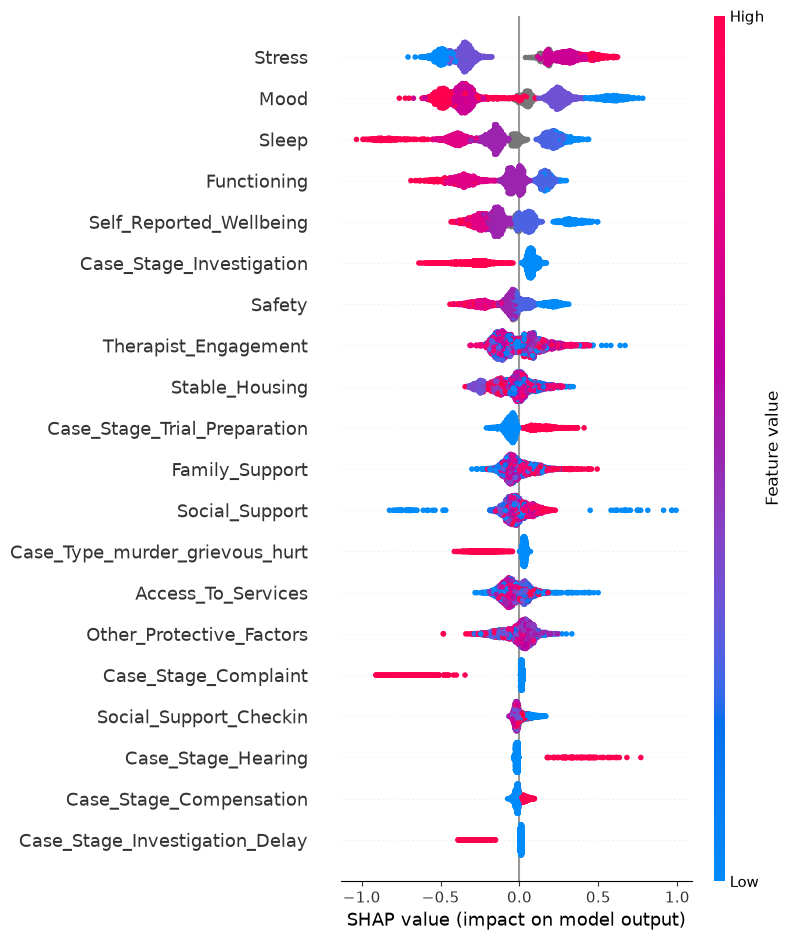

In [56]:
shap.summary_plot(
    shap_values,
    X_val_processed,
    max_display=20
)

In [59]:
shap_importance = pd.DataFrame({
    "feature": X_val_processed.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

print(
    shap_importance.head(20).to_string(index=False)
)

                       feature  mean_abs_shap
                        Stress       0.356828
                          Mood       0.337858
                         Sleep       0.248851
                   Functioning       0.171259
       Self_Reported_Wellbeing       0.158512
      Case_Stage_Investigation       0.141309
                        Safety       0.111828
          Therapist_Engagement       0.109295
                Stable_Housing       0.100383
  Case_Stage_Trial_Preparation       0.078243
                Family_Support       0.074242
                Social_Support       0.072946
Case_Type_murder_grievous_hurt       0.070963
            Access_To_Services       0.070003
      Other_Protective_Factors       0.068885
          Case_Stage_Complaint       0.048576
        Social_Support_Checkin       0.030026
            Case_Stage_Hearing       0.027463
       Case_Stage_Compensation       0.022054
Case_Stage_Investigation_Delay       0.022015


In [60]:
for col in [
    "Family_Support",
    "Social_Support",
    "Therapist_Engagement",
    "Access_To_Services",
    "Stable_Housing",
    "Other_Protective_Factors"
]:
    print("\n", col)
    print(model_df[col].value_counts(dropna=False))


 Family_Support
Family_Support
0.431    161
0.862    115
0.991    115
0.287    115
0.535    115
        ... 
0.721     23
0.652     23
0.355     23
0.868     23
0.409     23
Name: count, Length: 569, dtype: int64

 Social_Support
Social_Support
0.768    161
0.362    138
0.229    138
0.699    115
0.358    115
        ... 
0.990     23
0.745     23
0.747     23
0.218     23
0.401     23
Name: count, Length: 575, dtype: int64

 Therapist_Engagement
Therapist_Engagement
0.676    161
0.937    138
0.973    115
0.407    115
0.450    115
        ... 
0.563     23
0.433     23
0.807     23
0.332     23
0.991     23
Name: count, Length: 548, dtype: int64

 Access_To_Services
Access_To_Services
0.796    138
0.379    138
0.386    115
0.584    115
0.457    115
        ... 
0.668     23
0.438     23
0.587     23
0.256     23
0.757     23
Name: count, Length: 567, dtype: int64

 Stable_Housing
Stable_Housing
0.395    138
0.459    115
0.330    115
0.665    115
0.835    115
        ... 
0.386     23
0

In [61]:
print(
    model_df[
        [
            "Family_Support",
            "Social_Support",
            "Therapist_Engagement",
            "Access_To_Services",
            "Stable_Housing",
            "Other_Protective_Factors",
            "Future_Escalation_Label"
        ]
    ].groupby(
        "Future_Escalation_Label"
    ).mean()
)

                         Family_Support  Social_Support  Therapist_Engagement  \
Future_Escalation_Label                                                         
0.0                            0.604497        0.593063              0.647410   
1.0                            0.594457        0.613745              0.641341   

                         Access_To_Services  Stable_Housing  \
Future_Escalation_Label                                       
0.0                                0.597783        0.653404   
1.0                                0.594966        0.648517   

                         Other_Protective_Factors  
Future_Escalation_Label                            
0.0                                      0.619000  
1.0                                      0.617129  


In [62]:
final_test_prob = final_candidate.predict_proba(
    X_test_processed
)[:, 1]

In [63]:
print(
    "TEST ROC-AUC:",
    roc_auc_score(y_test, final_test_prob)
)

print(
    "TEST PR-AUC:",
    average_precision_score(y_test, final_test_prob)
)

TEST ROC-AUC: 0.8061785300873655
TEST PR-AUC: 0.2443706631635631


In [64]:
final_test_pred = (
    final_test_prob >= 0.16
).astype(int)

In [65]:
print(
    classification_report(
        y_test,
        final_test_pred,
        digits=4
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        final_test_pred
    )
)

              precision    recall  f1-score   support

           0     0.9552    0.9374    0.9462      3227
           1     0.2862    0.3632    0.3202       223

    accuracy                         0.9003      3450
   macro avg     0.6207    0.6503    0.6332      3450
weighted avg     0.9119    0.9003    0.9057      3450

Confusion Matrix:
[[3025  202]
 [ 142   81]]


In [66]:
import os

os.makedirs("structured_engine", exist_ok=True)

In [67]:
import joblib

joblib.dump(
    final_candidate,
    "structured_engine/xgboost_model.pkl"
)

joblib.dump(
    encoder,
    "structured_engine/case_encoder.pkl"
)

joblib.dump(
    episode_mapping,
    "structured_engine/episode_mapping.pkl"
)

joblib.dump(
    structured_features,
    "structured_engine/structured_features.pkl"
)

joblib.dump(
    X_train_processed.columns.tolist(),
    "structured_engine/model_columns.pkl"
)

joblib.dump(
    0.16,
    "structured_engine/threshold.pkl"
)

print("Structured Engine artifacts saved.")

Structured Engine artifacts saved.


In [18]:
print(type(encoder))
print(encoder)

NameError: name 'encoder' is not defined

In [69]:
print(X_train_processed.columns.tolist())

['Mood', 'Stress', 'Sleep', 'Functioning', 'Safety', 'Social_Support_Checkin', 'Self_Reported_Wellbeing', 'Threat_Event', 'Upcoming_Hearing', 'Hearing_Completed', 'Investigation_Delay', 'Compensation_Delay', 'Relocation_Stress', 'Rehabilitation_Issue', 'Protection_Event', 'Family_Support', 'Social_Support', 'Therapist_Engagement', 'Access_To_Services', 'Stable_Housing', 'Other_Protective_Factors', 'Recent_Episode', 'Family_Reported_Episode', 'Episode_Severity', 'Case_Type_arson_displacement', 'Case_Type_caste_based_violence', 'Case_Type_compensation_rehabilitation', 'Case_Type_murder_grievous_hurt', 'Case_Type_sexual_violence', 'Case_Type_witness_intimidation', 'Case_Stage_Compensation', 'Case_Stage_Complaint', 'Case_Stage_Hearing', 'Case_Stage_Investigation', 'Case_Stage_Investigation_Delay', 'Case_Stage_Post_Hearing', 'Case_Stage_Trial_Preparation']


In [70]:
print(episode_mapping)

{'Low': 1, 'Moderate': 2, 'High': 3}


In [19]:
sample = test_df.iloc[[0]].copy()

In [20]:
sample_input = sample[structured_features].copy()

In [21]:
import importlib
import inference

# Force reload the module to fetch the new function
importlib.reload(inference)

# Import the function
from inference import structured_risk_inference


In [22]:
result = structured_risk_inference(
    sample_input
)

print(result)

    structured_risk  structured_flag  threshold
60         0.013431                0       0.16


In [77]:


sample = test_df.iloc[[60]].copy()
from inference import structured_engine_api

output = structured_engine_api(sample)

print(output)


[{'structured_available': True, 'structured_risk': 0.005722885951399803, 'structured_flag': 0, 'threshold': 0.16, 'top_contributors': [{'feature': 'DDS', 'display_name': 'Current distress score', 'contribution': -0.9688376188278198}, {'feature': 'Previous_DDS', 'display_name': 'Previous distress score', 'contribution': -0.9041951298713684}, {'feature': 'Baseline_DDS', 'display_name': 'Baseline distress level', 'contribution': -0.42206358909606934}, {'feature': 'Engagement_Deviation', 'display_name': 'Change in engagement', 'contribution': 0.21797339618206024}, {'feature': 'Engagement_Score', 'display_name': 'Engagement level', 'contribution': -0.16250474750995636}]}]
